# Perturbation Diagnostics for Online AFC

This notebook inspects **what perturbations actually do to the alarm-event data** before the perturbed episodes are evaluated by the AFC benchmark. It is intended for scientific sanity checks, figure generation, and method-development discussions.

It covers four diagnostic layers:

1. **Dataset-level perturbation metrics** aggregated over episodes, severities, and Monte-Carlo draws.
2. **Episode-level perturbation comparisons** for selected alarm floods.
3. **Online update mechanics**, i.e. at which local times the online classifier is called and which prefix events are available.
4. **Prefix-trained classifier mechanics** for WDI-1NN and CASIM, i.e. which clean training prefixes define each prefix-specific classifier and which prefix classifier is selected during inference.

The notebook uses event-count progress as an analysis coordinate if your YAML sets `progress_reference: event_count`. This requires knowing the total number of events in the repaired perturbed episode. That is acceptable for benchmarking comparability, but it should not be interpreted as deployment-time knowledge.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split

# Make the notebook robust when executed from notebooks/ or from the repository root.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from afc_robustness.diagnostics import (
    aggregate_diagnostic_metrics,
    compare_episodes,
    compute_update_table,
    dataset_perturbation_metrics,
    event_table,
    perturb_episode_trace,
    plot_alarm_state_matrix,
    plot_episode_timeline,
    plot_metric_heatmap,
    plot_metric_vs_severity,
    plot_perturbation_comparison,
    plot_prefix_inference_selection,
    plot_prefix_training_coverage,
    prefix_boundary_table,
    prefix_inference_table,
    prefix_model_descriptions,
    prefix_training_plan,
)
from afc_robustness.experiment import (
    BenchmarkConfig,
    build_online_config,
    load_dataset_from_config,
)
from afc_robustness.online import prefix_by_time
from afc_robustness.repair import TraceRepair

## 1. Load configuration and dataset

Choose the config that defines the dataset, perturbation scenarios, severity grid, online update interval, progress grid, and prefix-training parameters.

In [2]:
CONFIG_PATH = REPO_ROOT / "configs" / "fcc.yaml"  # Change to tep.yaml or smoke.yaml if needed.

cfg = BenchmarkConfig.from_yaml(CONFIG_PATH)
dataset = load_dataset_from_config(cfg)
online_config = build_online_config(cfg, dataset)

print(f"Dataset: {dataset.name}")
print(f"Episodes: {dataset.n_episodes}")
print(f"Alarm tags: {dataset.n_tags}")
print(f"Max time steps: {dataset.n_time_steps}")
print(f"Online progress reference: {online_config.progress_reference}")
print(f"Online update interval: {online_config.update_interval}")
print(f"Progress grid: {online_config.progress_grid}")

Dataset: fcc
Episodes: 1600
Alarm tags: 57
Max time steps: 60
Online progress reference: relative_time
Online update interval: 10.0
Progress grid: (0.1666667, 0.3333333, 0.5, 0.6666667, 0.8333333, 1.0)


## 2. Diagnostic settings

The dataset-level block can be computationally non-trivial because it loops over:

```text
perturbation scenario × severity × draw × episode
```

Use `SAMPLE_INDICES_FOR_DATASET_METRICS = None` for the full dataset. For quick debugging, pass a short list such as `list(range(20))`.

In [3]:
bcfg = cfg.benchmark_config

SEVERITY_GRID_DIAGNOSTIC = bcfg.get(
    "severity_grid",
    [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.65, 0.80, 0.90],
)
N_DRAWS_DIAGNOSTIC = int(bcfg.get("n_draws", 5))

# Set to None for the entire dataset. Use a list of indices for quick exploratory runs.
SAMPLE_INDICES_FOR_DATASET_METRICS = None

INITIAL_ACTIVE_POLICY = str(bcfg.get("initial_active_policy", "act"))
ALLOW_LEADING_RTN = bool(bcfg.get("allow_leading_rtn", True))

# Example episode and perturbation used in the episode-level plots below.
EXAMPLE_INDEX = 0
EXAMPLE_SEED = int(cfg.random_seed)
EXAMPLE_SEVERITY = 0.30
EXAMPLE_PERTURBATION = {"name": "timing_uncertainty_example", "type": "timing_uncertainty", "max_shift": 3.0}

# Progress reporting for the potentially long dataset-level diagnostic loop.
VERBOSE_DIAGNOSTICS = True
DIAGNOSTIC_PROGRESS_UNIT = "sample"  # "sample" is more informative; "block" has slightly lower overhead.

print(f"Diagnostic severities: {SEVERITY_GRID_DIAGNOSTIC}")
print(f"Diagnostic draws: {N_DRAWS_DIAGNOSTIC}")

Diagnostic severities: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Diagnostic draws: 10


## 3. Dataset-level perturbation metrics

The table below distinguishes metrics for **activations only** from metrics for **ACT/RTN event streams**.

Useful activation-only metrics:

- `act_count_delta`: change in number of ACT events.
- `act_tag_set_jaccard`: overlap of unique activated tags.
- `act_tag_multiset_jaccard`: overlap of activation counts per tag, ignoring time.
- `act_tag_time_multiset_jaccard`: overlap of activation events by tag and time bin.
- `act_sequence_lcs_similarity`: order similarity of activation-tag sequences.

Useful ACT/RTN metrics:

- `event_count_delta`: change in total number of ACT and RTN events.
- `all_tag_type_multiset_jaccard`: overlap of `(tag, event_type)` event counts.
- `all_tag_type_time_multiset_jaccard`: overlap of `(tag, event_type, time_bin)` events.
- `all_sequence_lcs_similarity`: order similarity of full ACT/RTN sequences.
- `state_hamming_fraction` and `state_active_cell_jaccard`: reconstructed binary alarm-state matrix changes.

For late-detection perturbations, remember that the perturbed episode is re-referenced to a shifted local start. The state-matrix metrics are therefore local-window diagnostics, not absolute physical-time comparisons.

In [4]:
metrics_df = dataset_perturbation_metrics(
    dataset,
    cfg.perturbation_specs,
    severity_grid=SEVERITY_GRID_DIAGNOSTIC,
    n_draws=N_DRAWS_DIAGNOSTIC,
    sample_indices=SAMPLE_INDICES_FOR_DATASET_METRICS,
    random_seed=cfg.random_seed,
    dt=dataset.dt,
    initial_active_policy=INITIAL_ACTIVE_POLICY,
    allow_leading_rtn=ALLOW_LEADING_RTN,
    include_unrepaired=True,
    verbose=VERBOSE_DIAGNOSTICS,
    progress=True,
    progress_unit=DIAGNOSTIC_PROGRESS_UNIT,
)

agg_df = aggregate_diagnostic_metrics(metrics_df)

out_dir = cfg.output_dir / "diagnostics"
out_dir.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(out_dir / "perturbation_diagnostics_raw.csv", index=False)
agg_df.to_csv(out_dir / "perturbation_diagnostics_aggregated.csv", index=False)

print(f"Raw diagnostic rows: {len(metrics_df):,}")
print(f"Wrote diagnostics to: {out_dir}")
agg_df.head()

c:\Users\gianl\Documents\Code\Robustness-Benchmarking-for-Online-Alarm-Flood-Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Perturbation diagnostics: dataset='fcc', scenarios=6, severities=13, draws=10, samples=1600, variants=2, expected_rows=2,496,000.
Progress unit: sample; include_unrepaired=True; initial_active_policy='act'; allow_leading_rtn=True.


Perturbation diagnostics: 100%|██████████| 1248000/1248000 [24:28<00:00, 849.94sample/s, scenario=mixed_spurious_timing_late, severity=0.9, draw=10] 


Perturbation diagnostics finished: generated 2,496,000 rows.
Raw diagnostic rows: 2,496,000
Wrote diagnostics to: C:\Users\gianl\Documents\Code\Robustness-Benchmarking-for-Online-Alarm-Flood-Classification\results\fcc\diagnostics


,scenario,severity,variant,n_tags_mean,clean_horizon_mean,perturbed_horizon_mean,horizon_delta_mean,horizon_ratio_mean,clean_n_events_mean,perturbed_n_events_mean,...,all_tag_type_multiset_jaccard_p95,act_tag_time_multiset_jaccard_p95,all_tag_type_time_multiset_jaccard_p95,act_sequence_lcs_similarity_p95,all_sequence_lcs_similarity_p95,state_hamming_fraction_p95,state_active_cell_jaccard_p95,state_clean_active_cells_p95,state_perturbed_active_cells_p95,state_active_cell_ratio_p95
0,late_time_delay,0.00,repaired,57.0,59.0,59.000000,0.000000,1.000000,16.085,16.085000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,888.1,888.10,1.000000
1,late_time_delay,0.00,unrepaired,57.0,59.0,59.000000,0.000000,1.000000,16.085,16.085000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,888.1,888.10,1.000000
2,late_time_delay,0.05,repaired,57.0,59.0,56.054750,-2.945250,0.950081,16.085,11.260000,...,0.909091,0.030303,0.027065,0.888889,0.909091,0.151754,0.823562,888.1,538.05,0.952409
3,late_time_delay,0.05,unrepaired,57.0,59.0,56.054750,-2.945250,0.950081,16.085,11.260000,...,0.909091,0.030303,0.027065,0.888889,0.909091,0.151754,0.823562,888.1,538.05,0.952409
4,late_time_delay,0.10,repaired,57.0,59.0,53.132688,-5.867312,0.900554,16.085,10.049375,...,0.882353,0.000000,0.024421,0.857619,0.882353,0.183363,0.657631,888.1,464.10,0.914821


## 4. Dataset-level plots

These plots are intended to reveal whether a perturbation changes mostly the activation vocabulary, event order, event timing, or reconstructed alarm-state durations.

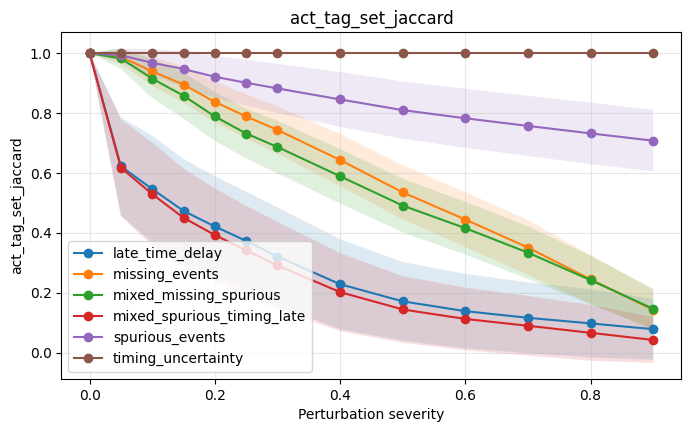

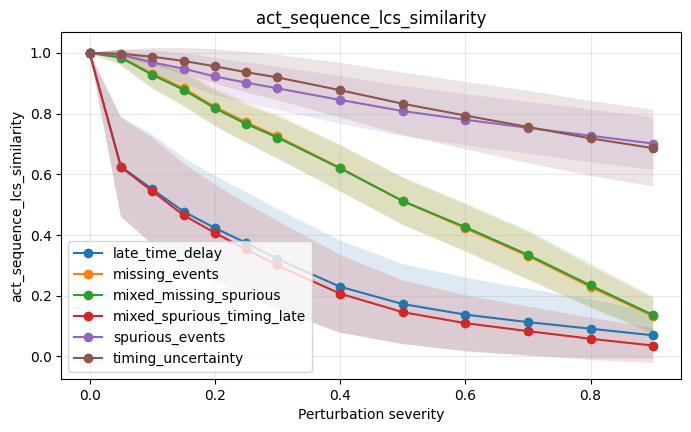

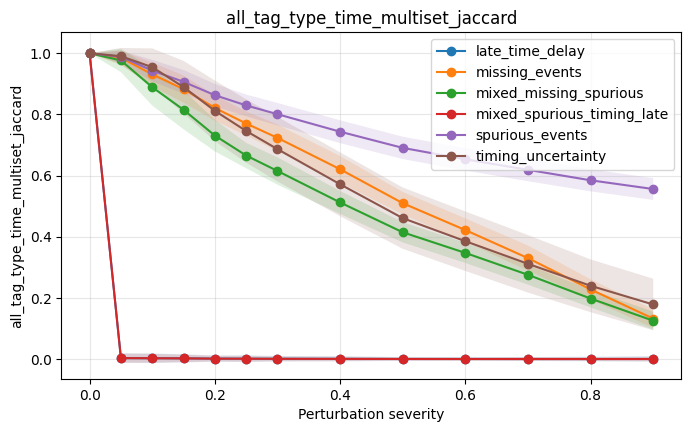

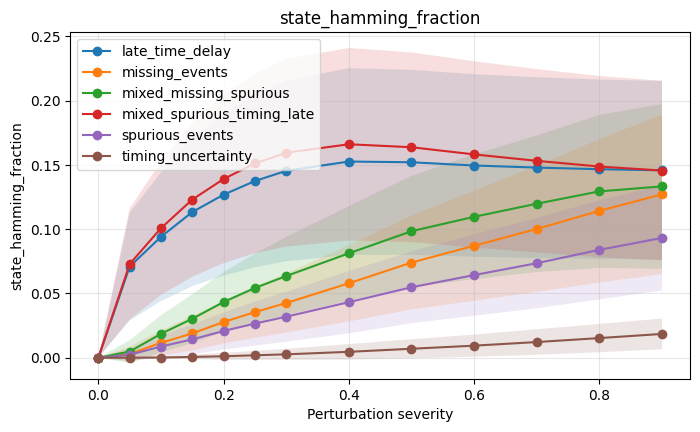

In [5]:
# Activation-only preservation of unique alarm tags.
plot_metric_vs_severity(metrics_df, "act_tag_set_jaccard", variant="repaired")
plt.show()

# Activation sequence order preservation.
plot_metric_vs_severity(metrics_df, "act_sequence_lcs_similarity", variant="repaired")
plt.show()

# Full ACT/RTN event-stream preservation with time bins.
plot_metric_vs_severity(metrics_df, "all_tag_type_time_multiset_jaccard", variant="repaired")
plt.show()

# Binary alarm-state perturbation magnitude.
plot_metric_vs_severity(metrics_df, "state_hamming_fraction", variant="repaired")
plt.show()

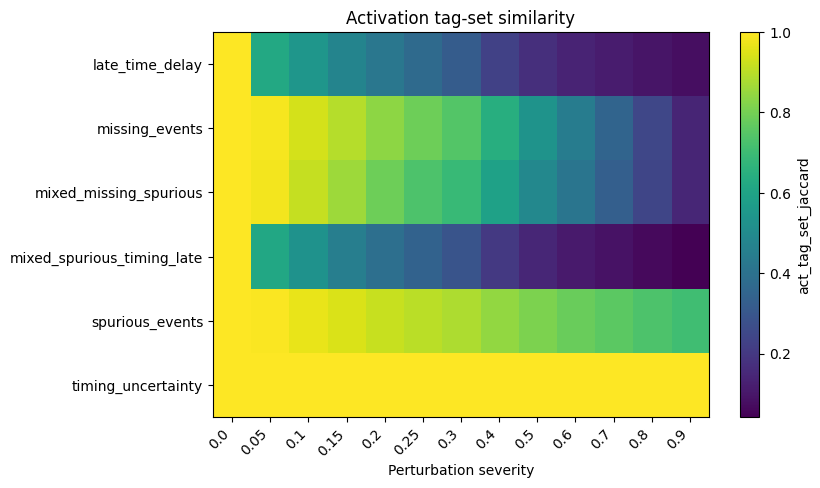

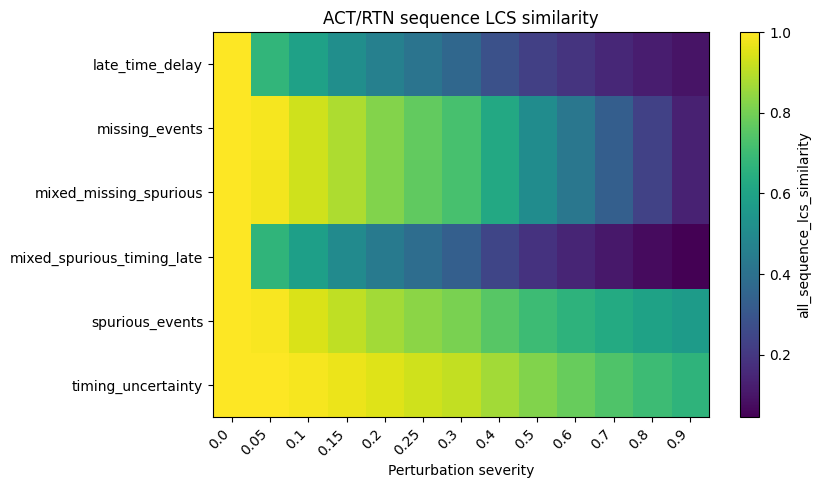

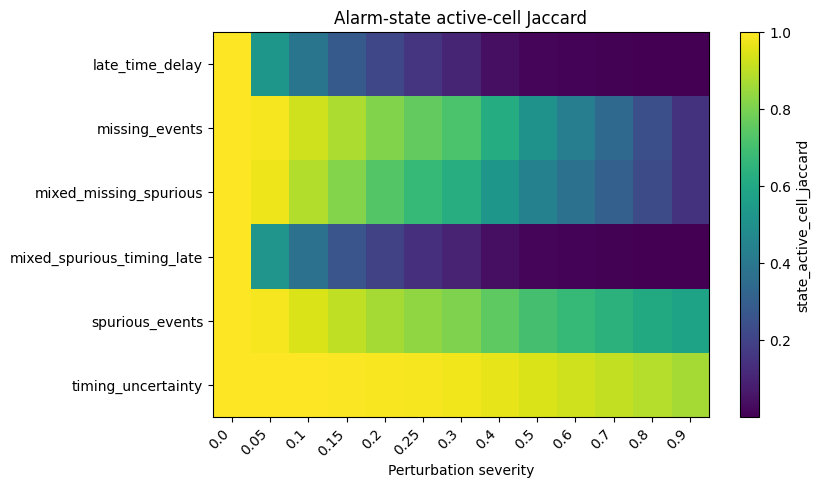

In [6]:
plot_metric_heatmap(metrics_df, "act_tag_set_jaccard", variant="repaired", title="Activation tag-set similarity")
plt.show()

plot_metric_heatmap(metrics_df, "all_sequence_lcs_similarity", variant="repaired", title="ACT/RTN sequence LCS similarity")
plt.show()

plot_metric_heatmap(metrics_df, "state_active_cell_jaccard", variant="repaired", title="Alarm-state active-cell Jaccard")
plt.show()

## 5. Episode-level perturbation inspection

This section compares a clean episode, its unrepaired perturbed version, and the repaired version actually passed to the classifiers.

In [7]:
clean_episode = dataset.episode(EXAMPLE_INDEX, initial_active_policy=INITIAL_ACTIVE_POLICY)
repair = TraceRepair(allow_leading_rtn=ALLOW_LEADING_RTN)
trace = perturb_episode_trace(
    clean_episode,
    EXAMPLE_PERTURBATION,
    severity=EXAMPLE_SEVERITY,
    seed=EXAMPLE_SEED,
    repair=repair,
)

comparison = pd.DataFrame(
    [
        {"variant": "unrepaired", **compare_episodes(trace.clean, trace.perturbed, dt=dataset.dt)},
        {"variant": "repaired", **compare_episodes(trace.clean, trace.repaired, dt=dataset.dt)},
    ]
)
comparison.T

,0,1
variant,unrepaired,repaired
sample_id,catalyst_deactivation/catalyst_deactivation_ru...,catalyst_deactivation/catalyst_deactivation_ru...
n_tags,57,57
clean_horizon,59.0,59.0
perturbed_horizon,59.0,59.0
horizon_delta,0.0,0.0
horizon_ratio,1.0,1.0
clean_n_events,14,14
perturbed_n_events,14,14
event_count_delta,0,0


In [8]:
# Event tables are often the easiest way to debug edge cases such as leading RTN events.
clean_events = event_table(trace.clean).assign(variant="clean")
perturbed_events = event_table(trace.perturbed).assign(variant="perturbed")
repaired_events = event_table(trace.repaired).assign(variant="repaired")
example_events = pd.concat([clean_events, perturbed_events, repaired_events], ignore_index=True)
example_events.head(40)

,event_index,timestamp,tag,tag_name,event_type,order,variant
0,0,0.000000,30,FIR100_high_alarm,ACT,6,clean
1,1,0.000000,52,FIR125_high_alarm,ACT,12,clean
2,2,1.000000,2,LIR100_high_alarm,ACT,0,clean
3,3,6.000000,45,FIR122_low_alarm,ACT,9,clean
4,4,7.000000,25,TIR122_low_alarm,ACT,4,clean
5,5,7.000000,48,FIR123_high_alarm,ACT,10,clean
6,6,10.000000,26,TIR122_lowlow_alarm,ACT,5,clean
7,7,13.000000,21,TIR121_low_alarm,ACT,2,clean
8,8,16.000000,22,TIR121_lowlow_alarm,ACT,3,clean
9,9,23.000000,43,FIR121_low_alarm,ACT,8,clean


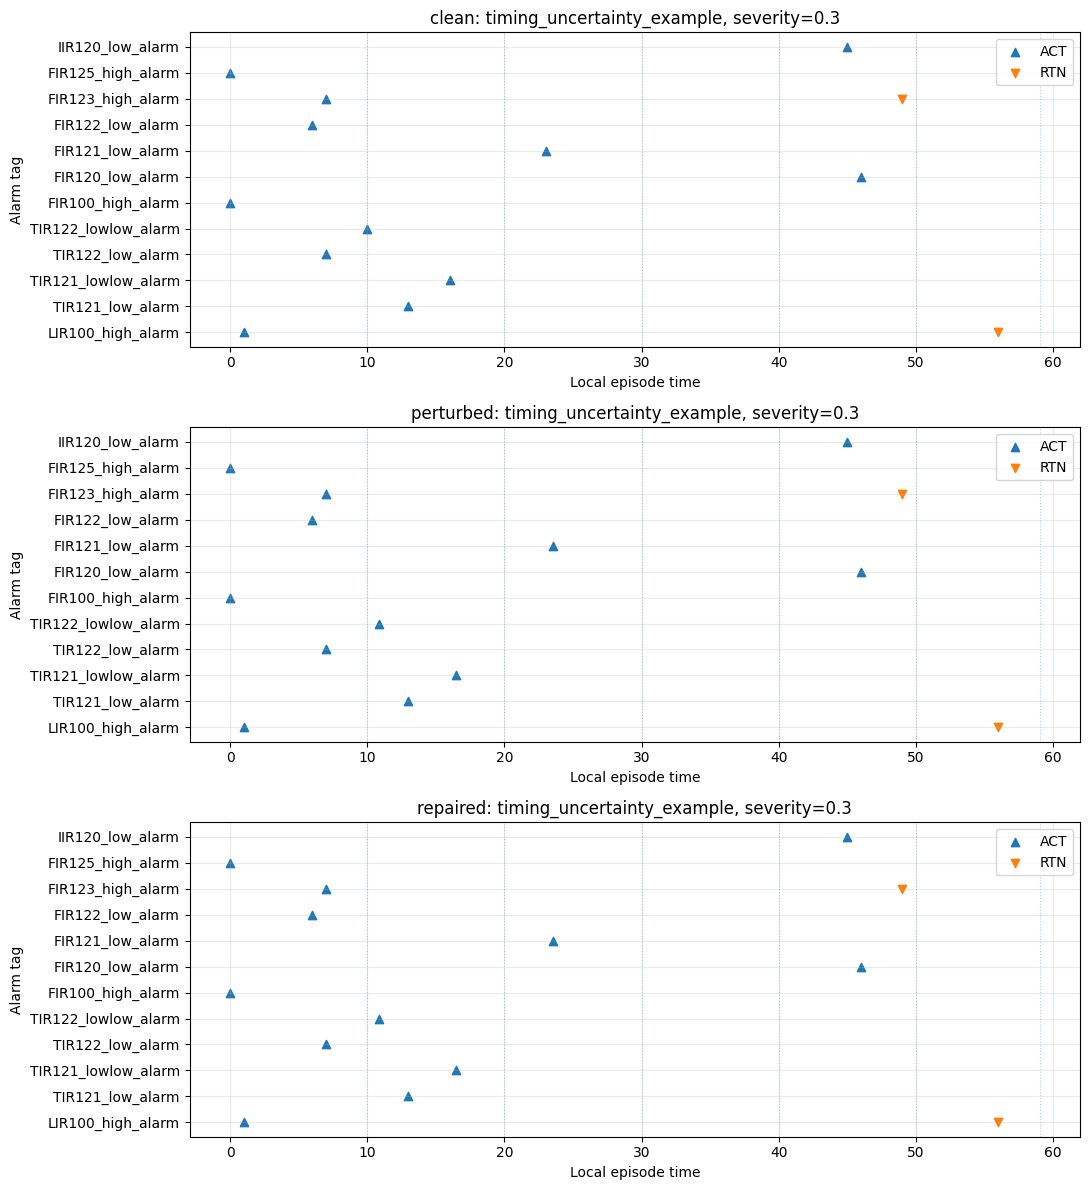

In [9]:
plot_perturbation_comparison(trace, online_config=online_config, event_mode="all", max_tags=40)
plt.show()

## 6. Online update mechanics for one alarm flood

The benchmark uses a time-driven update schedule. At each update time, only events with `timestamp <= update_time` are available. The table shows exactly which prefix is visible at each update and how this maps to event-count and relative-time progress.

In [10]:
updates_clean = compute_update_table(trace.clean, online_config)
updates_repaired = compute_update_table(trace.repaired, online_config)

updates_clean[[
    "update_index",
    "update_time",
    "benchmark_progress",
    "event_count_progress",
    "relative_time_progress",
    "n_events_observed",
    "n_act_observed",
    "n_rtn_observed",
    "act_tag_names_observed",
]].head(20)

,update_index,update_time,benchmark_progress,event_count_progress,relative_time_progress,n_events_observed,n_act_observed,n_rtn_observed,act_tag_names_observed
0,0,10.0,0.169492,0.500000,0.169492,7,7,0,"(LIR100_high_alarm, TIR122_low_alarm, TIR122_l..."
1,1,20.0,0.338983,0.642857,0.338983,9,9,0,"(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
2,2,30.0,0.508475,0.714286,0.508475,10,10,0,"(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
3,3,40.0,0.677966,0.714286,0.677966,10,10,0,"(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
4,4,50.0,0.847458,0.928571,0.847458,13,12,1,"(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
5,5,59.0,1.000000,1.000000,1.000000,14,12,2,"(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."


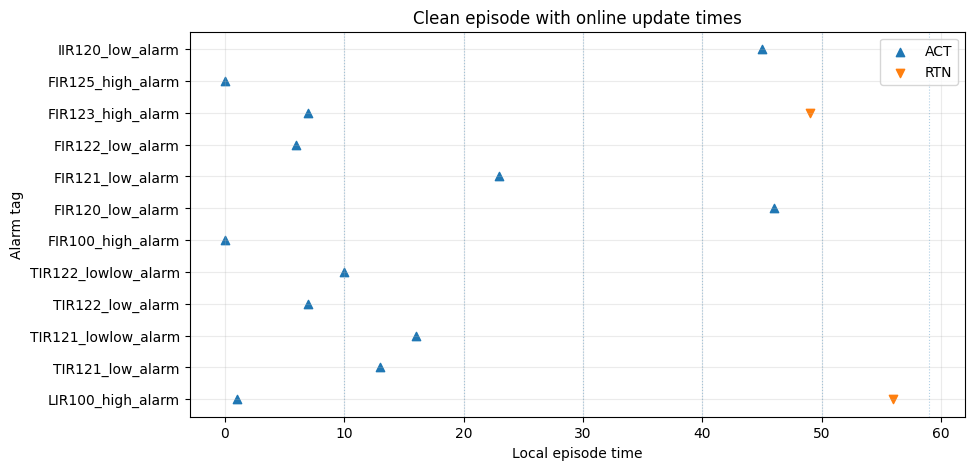

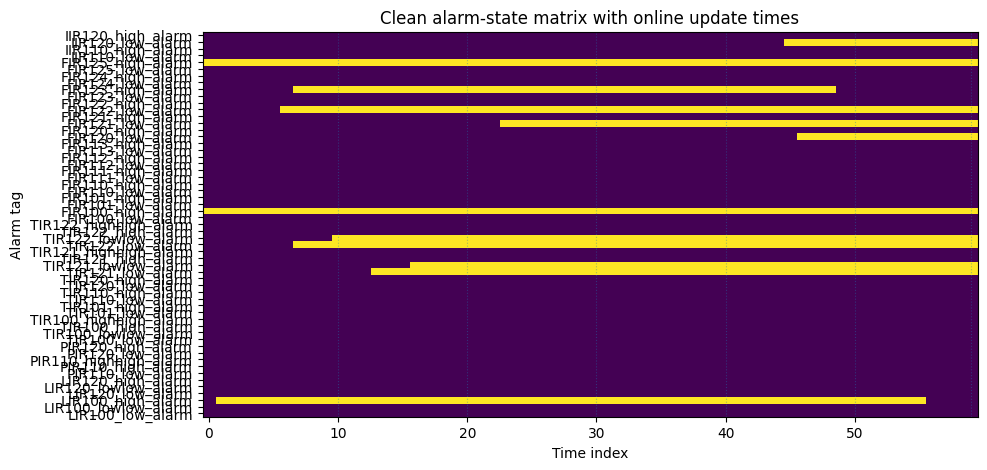

In [11]:
plot_episode_timeline(
    trace.clean,
    update_table=updates_clean,
    event_mode="all",
    annotate_updates=False,
    title="Clean episode with online update times",
)
plt.show()

plot_alarm_state_matrix(
    trace.clean,
    update_table=updates_clean,
    dt=dataset.dt,
    title="Clean alarm-state matrix with online update times",
)
plt.show()

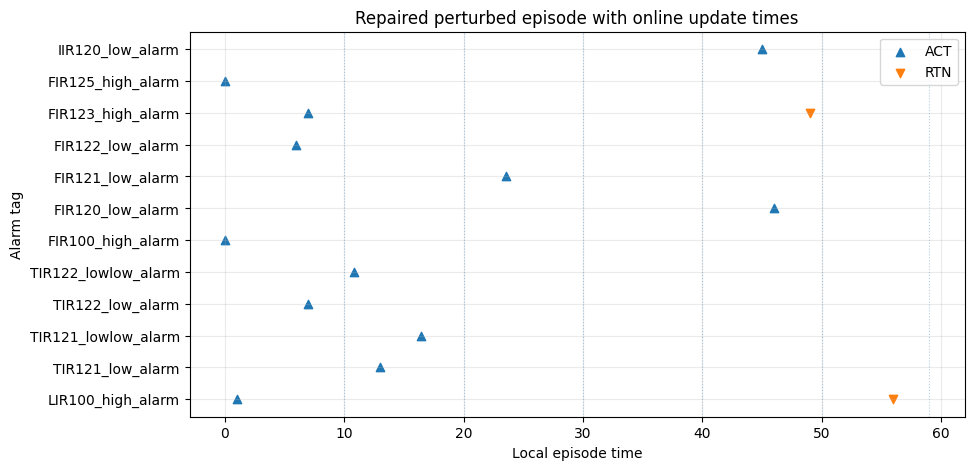

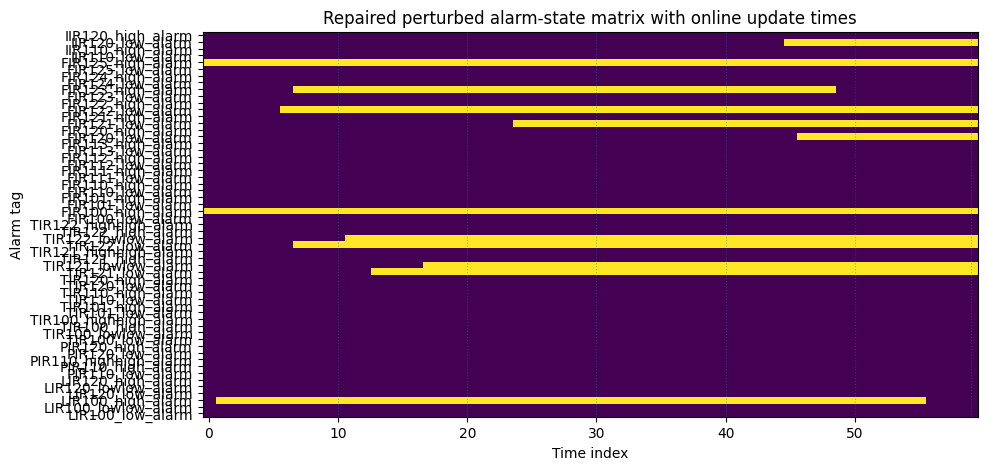

In [12]:
plot_episode_timeline(
    trace.repaired,
    update_table=updates_repaired,
    event_mode="all",
    annotate_updates=False,
    title="Repaired perturbed episode with online update times",
)
plt.show()

plot_alarm_state_matrix(
    trace.repaired,
    update_table=updates_repaired,
    dt=dataset.dt,
    title="Repaired perturbed alarm-state matrix with online update times",
)
plt.show()

### Inspect which events are used at a selected update

Change `SELECTED_UPDATE_INDEX` to inspect another online decision point.

In [13]:
SELECTED_UPDATE_INDEX = min(5, len(updates_clean) - 1)
selected_time = float(updates_clean.loc[SELECTED_UPDATE_INDEX, "update_time"])
selected_prefix = prefix_by_time(trace.clean, selected_time)

print(f"Selected update index: {SELECTED_UPDATE_INDEX}")
print(f"Selected update time: {selected_time}")
print(f"Events available: {selected_prefix.n_events} / {trace.clean.n_events}")
event_table(selected_prefix)

Selected update index: 5
Selected update time: 59.0
Events available: 14 / 14


,event_index,timestamp,tag,tag_name,event_type,order
0,0,0.0,30,FIR100_high_alarm,ACT,6
1,1,0.0,52,FIR125_high_alarm,ACT,12
2,2,1.0,2,LIR100_high_alarm,ACT,0
3,3,6.0,45,FIR122_low_alarm,ACT,9
4,4,7.0,25,TIR122_low_alarm,ACT,4
5,5,7.0,48,FIR123_high_alarm,ACT,10
6,6,10.0,26,TIR122_lowlow_alarm,ACT,5
7,7,13.0,21,TIR121_low_alarm,ACT,2
8,8,16.0,22,TIR121_lowlow_alarm,ACT,3
9,9,23.0,43,FIR121_low_alarm,ACT,8


## 7. Prefix-trained classifier mechanics: WDI-1NN and CASIM

This section reads the model settings from the YAML file and identifies classifiers with `training_mode: prefix`. For these models, the code summarizes which clean training prefixes define each prefix-specific subclassifier.

If the table is empty, add prefix training to the relevant model configs, for example:

```yaml
training_mode: prefix
prefix_grid: progress_grid
prefix_reference: event_count
prefix_train_reference: same
prefix_selection: left
prefix_train_horizon: prefix
```

In [14]:
prefix_models = prefix_model_descriptions(cfg.model_specs, online_config)
prefix_models

,model_key,method,param_index,prefix_grid,prefix_reference,prefix_train_reference,prefix_selection,prefix_train_horizon,prefix_min_time_steps
0,casim,CASIM-prefix,0,"(0.1666667, 0.3333333, 0.5, 0.6666667, 0.83333...",relative_time,relative_time,left,prefix,9


For the training-prefix summary, we use the first outer CV split to obtain the same kind of training partition as the benchmark. This is a diagnostic view; it does not fit any classifiers.

In [15]:
cv = cfg.cv_config
n_splits = int(cv.get("n_splits", 5))
n_repeats = int(cv.get("n_repeats", 10))
val_fraction = float(cv.get("validation_fraction", 0.2))

splitter = RepeatedStratifiedKFold(
    n_splits=n_splits,
    n_repeats=n_repeats,
    random_state=cfg.random_seed,
)
development_indices, test_indices = next(splitter.split(dataset.X, dataset.y))

if val_fraction > 0.0:
    train_indices, val_indices = train_test_split(
        development_indices,
        test_size=val_fraction,
        stratify=dataset.y[development_indices],
        random_state=cfg.random_seed,
    )
else:
    train_indices = development_indices
    val_indices = np.array([], dtype=int)

training_plan = prefix_training_plan(
    dataset,
    train_indices,
    cfg.model_specs,
    online_config,
    initial_active_policy=INITIAL_ACTIVE_POLICY,
)
training_plan.head(30)

,model_key,method,param_index,prefix_grid,prefix_reference,prefix_train_reference,prefix_selection,prefix_train_horizon,prefix_min_time_steps,prefix_progress,...,n_rtn_max,n_unique_act_tags_min,n_unique_act_tags_mean,n_unique_act_tags_max,horizon_min,horizon_mean,horizon_max,n_time_steps_min,n_time_steps_mean,n_time_steps_max
0,casim,CASIM-prefix,0,"(0.1666667, 0.3333333, 0.5, 0.6666667, 0.83333...",relative_time,relative_time,left,prefix,9,0.166667,...,7.0,1.0,6.674219,16.0,9.833335,9.833335,9.833335,10.0,10.0,10.0
1,casim,CASIM-prefix,0,"(0.1666667, 0.3333333, 0.5, 0.6666667, 0.83333...",relative_time,relative_time,left,prefix,9,0.333333,...,21.0,1.0,8.885156,19.0,19.666665,19.666665,19.666665,20.0,20.0,20.0
2,casim,CASIM-prefix,0,"(0.1666667, 0.3333333, 0.5, 0.6666667, 0.83333...",relative_time,relative_time,left,prefix,9,0.500000,...,21.0,1.0,10.378125,20.0,29.500000,29.500000,29.500000,30.0,30.0,30.0
3,casim,CASIM-prefix,0,"(0.1666667, 0.3333333, 0.5, 0.6666667, 0.83333...",relative_time,relative_time,left,prefix,9,0.666667,...,21.0,2.0,11.040625,22.0,39.333335,39.333335,39.333335,40.0,40.0,40.0
4,casim,CASIM-prefix,0,"(0.1666667, 0.3333333, 0.5, 0.6666667, 0.83333...",relative_time,relative_time,left,prefix,9,0.833333,...,28.0,2.0,11.590625,22.0,49.166665,49.166665,49.166665,50.0,50.0,50.0
5,casim,CASIM-prefix,0,"(0.1666667, 0.3333333, 0.5, 0.6666667, 0.83333...",relative_time,relative_time,left,prefix,9,1.000000,...,61.0,2.0,12.096875,23.0,59.000000,59.000000,59.000000,60.0,60.0,60.0


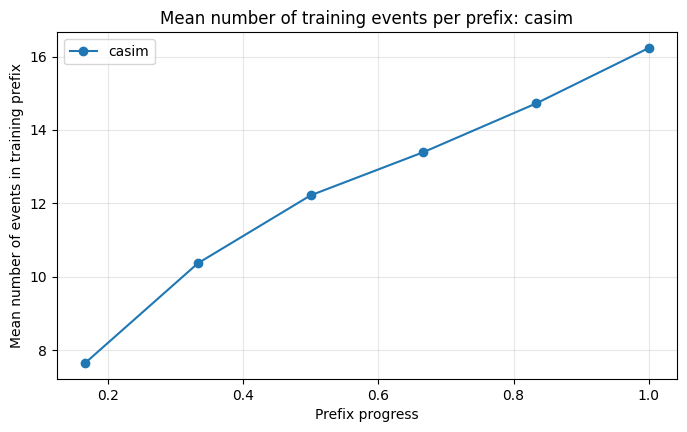

In [16]:
# Plot aggregate training-prefix coverage for each prefix-trained model.
if not training_plan.empty:
    for model_key, part in training_plan.groupby("model_key", sort=False):
        ax = plot_metric_vs_severity(
            part.rename(columns={"prefix_progress": "severity"}).assign(scenario=model_key, variant="repaired"),
            "n_events_mean",
            title=f"Mean number of training events per prefix: {model_key}",
        )
        ax.set_xlabel("Prefix progress")
        ax.set_ylabel("Mean number of events in training prefix")
        plt.show()

## 8. Prefix boundaries for a selected alarm flood

The following plot marks the parts of an example flood that would be used to train prefix-specific subclassifiers at each progress level. For event-count prefix training, the boundary time is the timestamp of the `ceil(rho * n_events)`-th event.

In [17]:
if not prefix_models.empty:
    first_prefix_model = prefix_models.iloc[0]
    prefix_grid = first_prefix_model["prefix_grid"]
    train_reference = first_prefix_model["prefix_train_reference"]
else:
    prefix_grid = online_config.progress_grid
    train_reference = online_config.progress_reference

clean_boundaries = prefix_boundary_table(
    trace.clean,
    prefix_grid,
    reference=train_reference,
    dt=dataset.dt,
)
repaired_boundaries = prefix_boundary_table(
    trace.repaired,
    prefix_grid,
    reference=train_reference,
    dt=dataset.dt,
)

clean_boundaries

,prefix_progress,boundary_time,n_events_used,n_act_used,n_rtn_used,n_unique_act_tags_used,act_tags_used,act_tag_names_used
0,0.166667,9.833335,6,6,0,6,"(2, 25, 30, 45, 48, 52)","(LIR100_high_alarm, TIR122_low_alarm, FIR100_h..."
1,0.333333,19.666665,9,9,0,9,"(2, 21, 22, 25, 26, 30, 45, 48, 52)","(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
2,0.500000,29.500000,10,10,0,10,"(2, 21, 22, 25, 26, 30, 43, 45, 48, 52)","(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
3,0.666667,39.333335,10,10,0,10,"(2, 21, 22, 25, 26, 30, 43, 45, 48, 52)","(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
4,0.833333,49.166665,13,12,1,12,"(2, 21, 22, 25, 26, 30, 41, 43, 45, 48, 52, 55)","(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
5,1.000000,59.000000,14,12,2,12,"(2, 21, 22, 25, 26, 30, 41, 43, 45, 48, 52, 55)","(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."


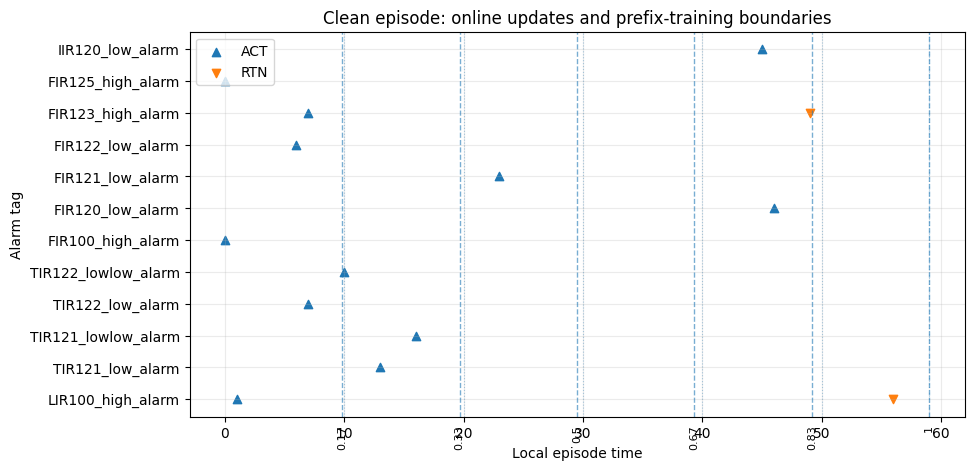

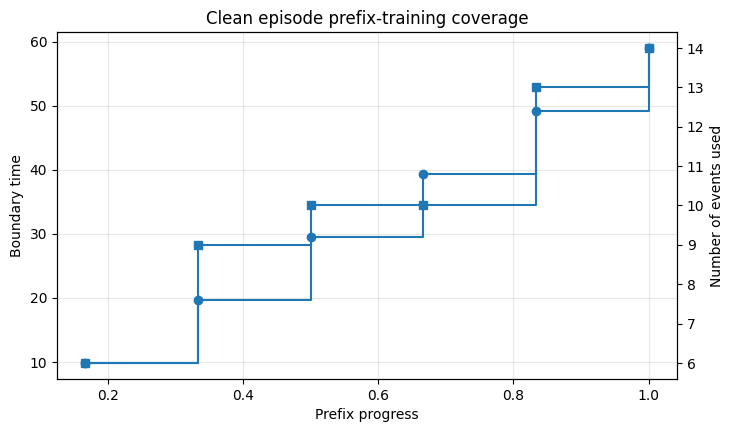

In [18]:
plot_episode_timeline(
    trace.clean,
    update_table=updates_clean,
    prefix_boundaries=clean_boundaries,
    event_mode="all",
    title="Clean episode: online updates and prefix-training boundaries",
)
plt.show()

plot_prefix_training_coverage(clean_boundaries, title="Clean episode prefix-training coverage")
plt.show()

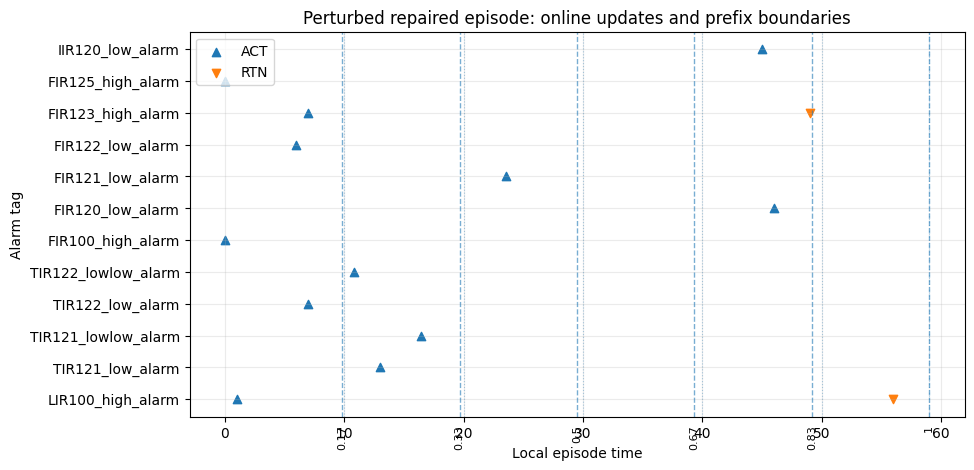

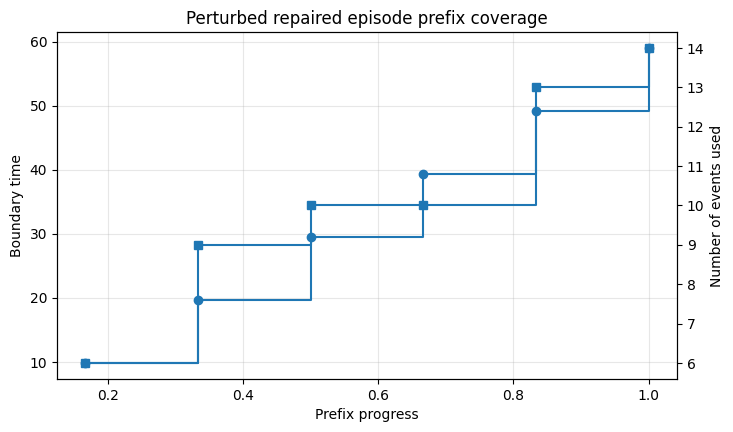

In [19]:
plot_episode_timeline(
    trace.repaired,
    update_table=updates_repaired,
    prefix_boundaries=repaired_boundaries,
    event_mode="all",
    title="Perturbed repaired episode: online updates and prefix boundaries",
)
plt.show()

plot_prefix_training_coverage(repaired_boundaries, title="Perturbed repaired episode prefix coverage")
plt.show()

## 9. Prefix classifier selected during inference

This view shows which prefix-specific classifier is selected at every online update. With `prefix_selection: left`, the selected classifier is the largest trained prefix progress that does not exceed the observed progress. Before the first grid point, the earliest prefix classifier is used.

In [20]:
clean_prefix_inference = prefix_inference_table(trace.clean, cfg.model_specs, online_config)
repaired_prefix_inference = prefix_inference_table(trace.repaired, cfg.model_specs, online_config)

clean_prefix_inference[[
    "model_key",
    "update_index",
    "update_time",
    "observed_selection_progress",
    "selected_prefix_progress",
    "n_events_observed",
    "n_act_observed",
    "act_tag_names_observed",
]].head(30)

,model_key,update_index,update_time,observed_selection_progress,selected_prefix_progress,n_events_observed,n_act_observed,act_tag_names_observed
0,casim,0,10.0,0.169492,0.166667,7,7,"(LIR100_high_alarm, TIR122_low_alarm, TIR122_l..."
1,casim,1,20.0,0.338983,0.333333,9,9,"(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
2,casim,2,30.0,0.508475,0.500000,10,10,"(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
3,casim,3,40.0,0.677966,0.666667,10,10,"(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
4,casim,4,50.0,0.847458,0.833333,13,12,"(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."
5,casim,5,59.0,1.000000,1.000000,14,12,"(LIR100_high_alarm, TIR121_low_alarm, TIR121_l..."


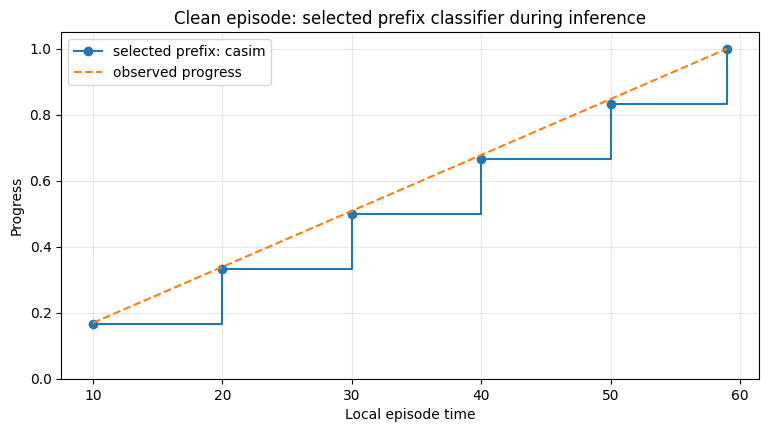

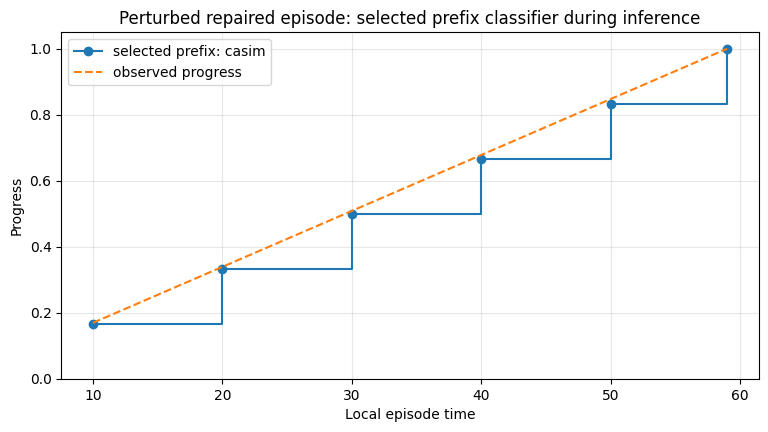

In [21]:
if not clean_prefix_inference.empty:
    plot_prefix_inference_selection(clean_prefix_inference, title="Clean episode: selected prefix classifier during inference")
    plt.show()

if not repaired_prefix_inference.empty:
    plot_prefix_inference_selection(repaired_prefix_inference, title="Perturbed repaired episode: selected prefix classifier during inference")
    plt.show()